# Imports and load data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# %matplotlib widget
# plt.rc('text', usetex = False)
plt.rcParams['font.size'] = 16
# plt.rcParams['figure.facecolor'] = 'w'
# plt.style.use('classic')

def customCMAP(names = ['hot_r', 'cool', 'bone_r', 'pink_r', 'plasma_r'], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.colormaps.register(cmap = map_object)

customCMAP()

window_radius = 1e-2 # m

# Electron charge in C
e_charge = 1.602176634e-19

# ILC parameters
n_incident = 2.5e10 # number of electrons per bunch
n_bunches = 1312 # number of bunches per pulse
ILC_scale = n_bunches * n_incident # number of electrons in a bunch train

density = {
    'LXe': 2.953 * 1e6, # g/m^3
    'Be' : 1.848 * 1e6, # g/m^3
    'Al' : 2.699 * 1e6, # g/m^3
}

# n_electrons_per_pulse = n_incident / 20 # 20 beam pulses per bunch train WRONG ==> 1.25e9 e- per pulse
n_electrons_per_pulse = 66 * n_incident # 2.5e10 e- per bunch, 66 bunches in a pulse
pulse_time_sep = 3.3e-3 # 3.3 ms between pulses


In [8]:
thicknesses = [ '0.5' , '2.0']
materials = ['Be', 'Al']

def entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/entrance_window.csv'

def exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/exit_window.csv'

def LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/LXe.csv'

def Silviu_entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_entrance_window.csv'

def Silviu_exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_exit_window.csv'

def Silviu_LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_LXe.csv'

In [9]:
mat_thick_ref = [[mat,thk] for thk in thicknesses for mat in materials]
print(mat_thick_ref)

entrance_data = [pd.read_csv(Silviu_entrance_win_path(mat, thk)) for thk in thicknesses for mat in materials]
exit_data = [pd.read_csv(Silviu_exit_win_path(mat, thk)) for thk in thicknesses for mat in materials]

[['Be', '0.5'], ['Al', '0.5'], ['Be', '2.0'], ['Al', '2.0']]


# Create multi-time-scale power deposition plot (exit window)

In [10]:
idx = 0

print(mat_thick_ref[idx])

# window_thickness = float(mat_thick_ref[1][1]) * 1e-3 # m
# window_volume = np.pi * window_radius**2 * window_thickness # m^3

Window_subvolume = 5e-10 # m^3 (0.5 mm window thickness)
data = exit_data[idx]

power_per_pulse_per_volume = data['PowerPerVolume'].sum() # one pulse is 66 bunches
power_per_pulse = power_per_pulse_per_volume * Window_subvolume
energy_per_pulse = power_per_pulse * pulse_time_sep # J
energy_dep_per_bunch = energy_per_pulse / 66 # J
print(f'Power deposited per pulse (66 bunches) : {power_per_pulse:.2e} W')
print(f'Energy deposited per pulse (66 bunches) : {power_per_pulse * pulse_time_sep:.2e} J')
print(f'Energy deposited per bunch : {energy_dep_per_bunch:.2e} J')

['Be', '0.5']
Power deposited per pulse (66 bunches) : 1.56e+02 W
Energy deposited per pulse (66 bunches) : 5.14e-01 J
Energy deposited per bunch : 7.79e-03 J


**Try:** energy per bunch / bunch length

In [11]:
# pulse_width = 474e-9
# pulse_sep = 3.3e-3
# train_duration = 63e-3

# for 33 bunches, we need a new bunch every 6.15 ns, then an 80 ns pause, then another set of 33 bunches. This is one pulse.
# Repeat for 20 pulses at 300 Hz, where each pulse occupies 474 ns of time.

In [12]:
bunch_sep = 6.15e-9 # s
half_pulse_sep = 80e-9
n_pulses = 20

bunch_time_half_pulse = np.arange(0, 33 * bunch_sep, bunch_sep)
bunch_time_pulse = np.hstack((bunch_time_half_pulse, (bunch_time_half_pulse[-1] + half_pulse_sep) + bunch_time_half_pulse))

pulse_sep = 3.3e-3 - bunch_time_pulse[-1] # 3.3 ms - 474 ns

bunch_time_train = np.hstack(tuple([ j*pulse_sep + bunch_time_pulse for j in range(n_pulses) ]))
cumulative_edep_per_bunch = [energy_dep_per_bunch * (i+1) for i in range(bunch_time_train.size)]

In [13]:
bunch_time_train

array([0.00000000e+00, 6.15000000e-09, 1.23000000e-08, ...,
       6.26914629e-02, 6.26914690e-02, 6.26914752e-02], shape=(1320,))

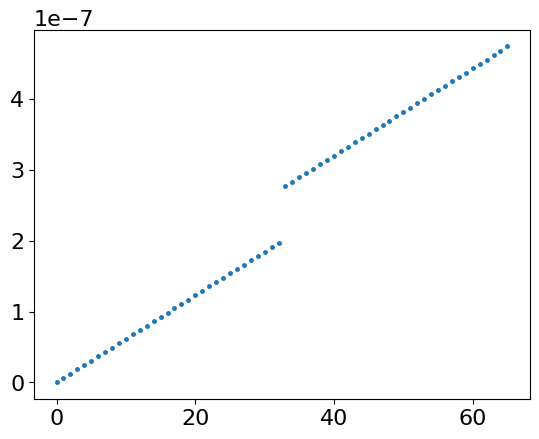

Time of last bunch in pulse 1 : 4.74e-07 s
Beginning of pulse 2 time : 3.30e-03 s
This agrees with the time structure: 474 ns pulse width and 3.3 ms per pulse


In [14]:
pulse_idx = 0

plt.close()
plt.figure()
plt.plot(bunch_time_train[pulse_idx * 66:(pulse_idx + 1) * 66], '.', ms='5')
plt.show()

print(f'Time of last bunch in pulse {pulse_idx + 1} : {bunch_time_train[(pulse_idx+1) * 65]:.2e} s')
if pulse_idx != n_pulses - 1:
    print(f'Beginning of pulse {pulse_idx + 2} time : {bunch_time_train[(pulse_idx+1) * 66]:.2e} s')

if pulse_idx == 0:
    print('This agrees with the time structure: 474 ns pulse width and 3.3 ms per pulse')
elif pulse_idx == n_pulses - 1:
    print('This agrees with the time structure: 63 ms per bunch train')

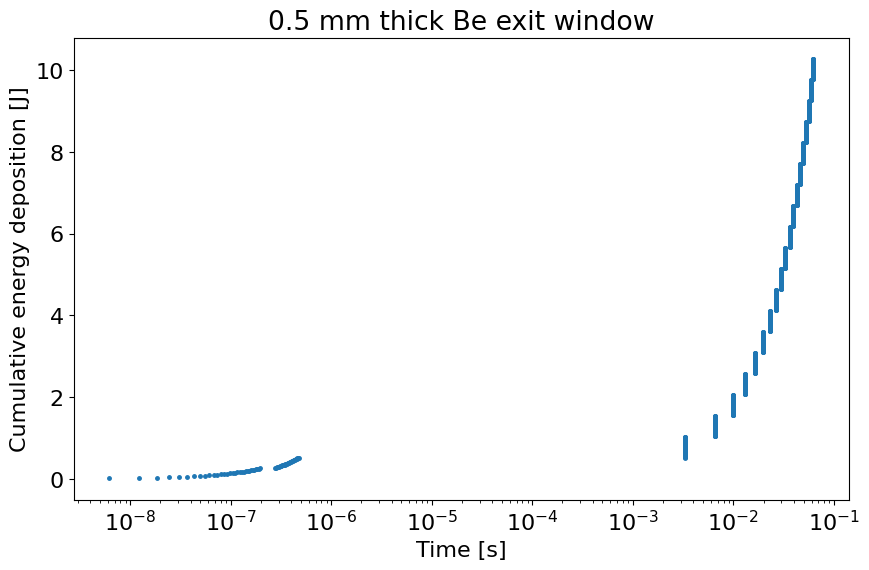

In [15]:
plt.close()
plt.figure(figsize=(10,6))

plt.semilogx(bunch_time_train, cumulative_edep_per_bunch, '.', ms=5)
# plt.plot(bunch_time_train, cumulative_edep_per_bunch, '.', ms=5)

plt.xlabel('Time [s]')
plt.ylabel('Cumulative energy deposition [J]')
# plt.suptitle('Bunch train viewed from the 20-pulse time structure')
plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')

plt.show()

In [16]:
dE = [energy_dep_per_bunch for i in range(len(bunch_time_train)-1)]
dt = np.diff(bunch_time_train)
# dt = np.diff(np.hstack(([0], bunch_time_train)))

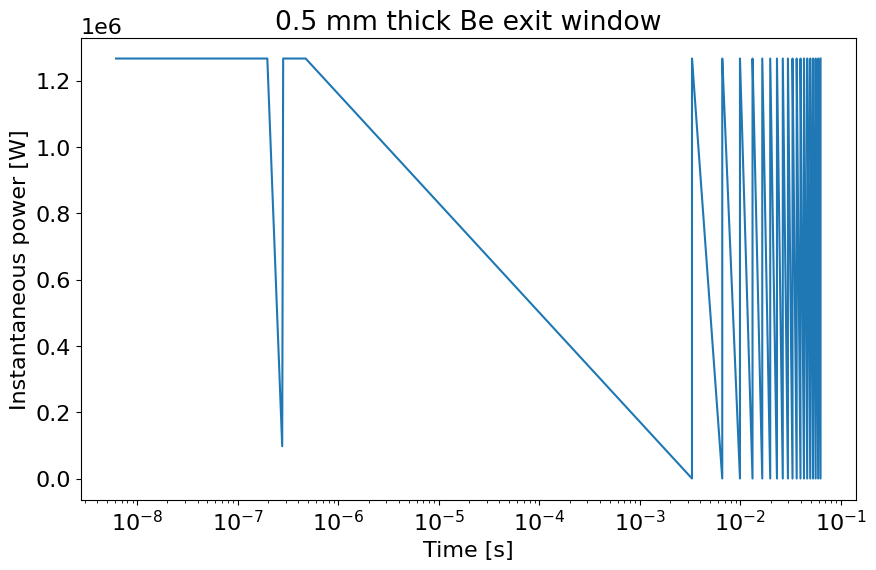

In [17]:
d=33
btt = bunch_time_train[1:]
plt.close()
plt.figure(figsize=(10,6))

plt.semilogx(bunch_time_train[1:], dE / dt)#, '.', ms=5, mec='b', mfc='none', alpha=0.5)
# plt.semilogx(bunch_time_train[1:], np.cumsum(dE / dt), '.', ms=5, mec='b', mfc='none', alpha=0.5)

# plt.semilogx(btt[::d], dE[::d] / dt[::d], 'r.', ms=5)
# plt.axhline(y=energy_dep_per_bunch / 6.15e-9, c='r')
# plt.axhline(y=energy_dep_per_bunch / 80e-9, c='tab:green', ls='--')
# plt.axhline(y=energy_dep_per_bunch / (3.3e-3-474e-9), c='k')

plt.xlabel('Time [s]')
plt.ylabel('Instantaneous power [W]')
# plt.ylabel('Cumulative power [W]') # doesn't really make sense since the time scales mix
plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')

plt.show()

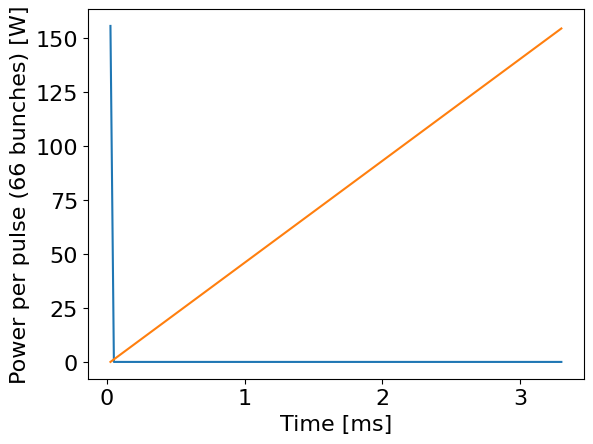

In [18]:
# each entry corresponds to a 25 µs interval
n_steps = 132
time_step = 25e-6 # s
spiky_power = [0 if i != 0 else power_per_pulse for i in range(n_steps)]
continuous_power = [ i * power_per_pulse / n_steps for i in range(n_steps) ]

time = np.arange(time_step, (n_steps+1) * time_step, time_step)

plt.close()
plt.figure()

plt.plot(time * 1e3, spiky_power)
plt.plot(time * 1e3, continuous_power)

plt.ylabel('Power per pulse (66 bunches) [W]')
plt.xlabel('Time [ms]')
plt.show()

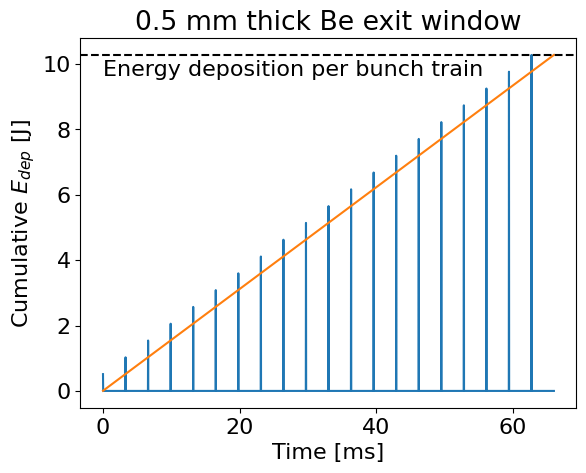

In [19]:
spiky_cumulative_edep_train = [0 if i%(n_steps) != 0 else (i//n_steps + 1) * energy_per_pulse for i in range(n_pulses * n_steps)]
continuous_cumulative_edep_train = [ (i+1) * energy_per_pulse / n_steps for i in range(n_pulses * n_steps) ]
time_train = np.arange(time_step, (n_pulses * n_steps+1) * time_step, time_step)

plt.close()
plt.figure()

plt.plot(time_train * 1e3, spiky_cumulative_edep_train, label='Discrete deposition')
plt.plot(time_train * 1e3, continuous_cumulative_edep_train, label='Continuous deposition')

# plt.axhline(y=energy_per_pulse, c='r')
plt.axhline(y=n_pulses * energy_per_pulse, c='k', ls='--')
plt.text(0, n_pulses * energy_per_pulse-0.65, s='Energy deposition per bunch train')

# plt.xlim(0, 3.3)

plt.ylabel('Cumulative $E_{dep}$ [J]')
plt.xlabel('Time [ms]')
plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')
# plt.legend(loc='center left')
# plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Edep_CFD_Implementations.png', dpi=500)
plt.show()

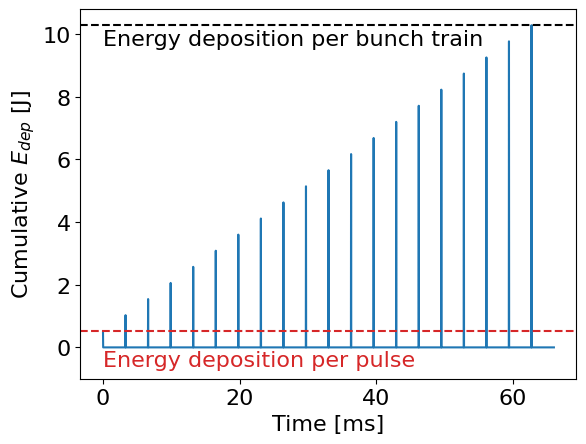

In [20]:
spiky_cumulative_edep_train = [0 if i%(n_steps) != 0 else (i//n_steps + 1) * energy_per_pulse for i in range(n_pulses * n_steps)]
continuous_cumulative_edep_train = [ (i+1) * energy_per_pulse / n_steps for i in range(n_pulses * n_steps) ]
time_train = np.arange(time_step, (n_pulses * n_steps+1) * time_step, time_step)

plt.close()
plt.figure()

plt.plot(time_train * 1e3, spiky_cumulative_edep_train, label='Discrete deposition')

plt.axhline(y=energy_per_pulse, c='tab:red', ls='--')
plt.text(0, energy_per_pulse-1.1, s='Energy deposition per pulse', c='tab:red')
plt.axhline(y=n_pulses * energy_per_pulse, c='k', ls='--')
plt.text(0, n_pulses * energy_per_pulse-0.65, s='Energy deposition per bunch train')

# plt.xlim(0, 3.3)
plt.ylim(bottom=-1)

plt.ylabel('Cumulative $E_{dep}$ [J]')
plt.xlabel('Time [ms]')
# plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')
# plt.suptitle('Temporal profile of energy deposition in ANSYS')
# plt.legend(loc='center left')
# plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Edep_CFD_Implementation.pdf', dpi=500, bbox_inches='tight')
plt.show()

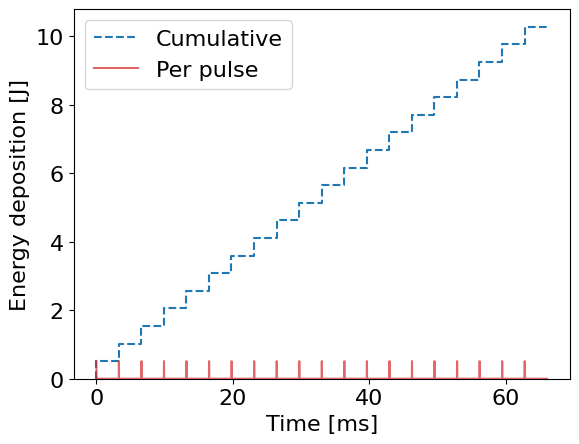

In [25]:
step_cumulative_edep_train = [energy_per_pulse*i for i in range(n_pulses+1)]
step_train_time = 1e3 * np.arange(0, (n_pulses + 1) * pulse_sep, pulse_sep)

time_train = 1e3 * np.arange(time_step, (n_pulses * n_steps+1) * time_step, time_step)
spiky_per_pulse_edep_train = [0 if i%(n_steps) != 0 else energy_per_pulse for i in range(n_pulses * n_steps)]

plt.close()
plt.figure()

# plt.plot(time_train * 1e3, spiky_cumulative_edep_train, label='Discrete deposition')
plt.step(step_train_time, step_cumulative_edep_train, c='tab:blue', ls='--', label='Cumulative')
plt.plot(time_train, spiky_per_pulse_edep_train, c='tab:red', ls='-', label='Per pulse', alpha=.7)
# plt.step(step_train_time, step_cumulative_edep_train, c='tab:blue', ls='--', label='Cumulative $E_{dep}$')
# plt.plot(time_train, spiky_per_pulse_edep_train, c='tab:red', ls='-', label='$E_{dep}$ per pulse', alpha=.7)

plt.ylim(bottom=0)

plt.ylabel('Energy deposition [J]')
# plt.ylabel('$E_{dep}$ [J]')
plt.xlabel('Time [ms]')
# plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')
# plt.suptitle('Temporal profile of energy deposition in ANSYS')
plt.legend()

plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Combo_Edep_CFD_Implementation.pdf', dpi=500, bbox_inches='tight')
plt.show()

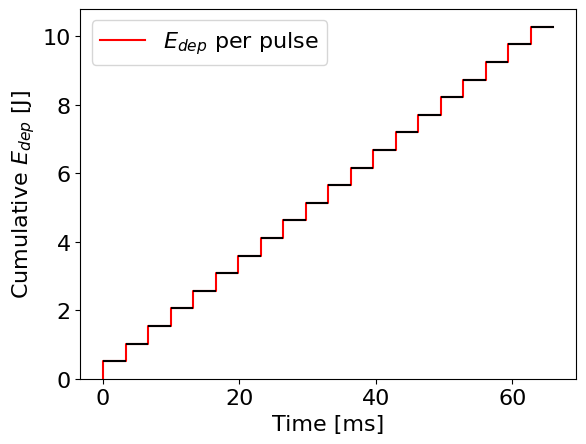

In [22]:
step_cumulative_edep_train = [energy_per_pulse*i for i in range(n_pulses+1)]
step_train_time = 1e3 * np.arange(0, (n_pulses + 1) * pulse_sep, pulse_sep)

y_hlines = step_cumulative_edep_train[1:]
xmin_hlines = step_train_time[:-1].copy()
xmax_hlines = step_train_time[1:].copy()
xmax_hlines[-1] += 1e-1

plt.close()
plt.figure()

# plt.plot(time_train * 1e3, spiky_cumulative_edep_train, label='Discrete deposition')
plt.step(step_train_time, step_cumulative_edep_train, c='r', label='$E_{dep}$ per pulse')
plt.hlines(y_hlines, xmin_hlines, xmax_hlines, color='k', label='_Cumulative $E_{dep}$')

# plt.axhline(y=energy_per_pulse, c='tab:red', ls='--')
# plt.text(0, energy_per_pulse-1.1, s='Energy deposition per pulse', c='tab:red')
# plt.axhline(y=n_pulses * energy_per_pulse, c='k', ls='--')
# plt.text(0, n_pulses * energy_per_pulse-0.65, s='Energy deposition per bunch train')

plt.ylim(bottom=0)

plt.ylabel('Cumulative $E_{dep}$ [J]')
plt.xlabel('Time [ms]')
# plt.title(f'{mat_thick_ref[idx][1]} mm thick {mat_thick_ref[idx][0]} exit window')
# plt.suptitle('Temporal profile of energy deposition in ANSYS')
plt.legend()

# plt.savefig('/Users/max/SLAC Fall 2024/LXeSims/Figures/Cumulative_Edep_CFD_Implementation.pdf', dpi=500, bbox_inches='tight')
plt.show()